In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'

os.makedirs('images', exist_ok=True)
os.makedirs('data', exist_ok=True)

print("✅ Libraries Imported Successfully")

✅ Libraries Imported Successfully


In [2]:
df = pd.read_csv('data/retail_sales_dataset.csv')

print("✅ Retail Sales Dataset Loaded")
print(f"Shape     : {df.shape}")
print(f"Columns   : {df.columns.tolist()}")
print(f"\nFirst 5 Rows:")
df.head()

✅ Retail Sales Dataset Loaded
Shape     : (1000, 9)
Columns   : ['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']

First 5 Rows:


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
menu = pd.read_csv('data/menu.csv')

print("✅ Menu Dataset Loaded")
print(f"Shape     : {menu.shape}")
print(f"Columns   : {menu.columns.tolist()}")
print(f"\nFirst 5 Rows:")
menu.head()

✅ Menu Dataset Loaded
Shape     : (260, 24)
Columns   : ['Category', 'Item', 'Serving Size', 'Calories', 'Calories from Fat', 'Total Fat', 'Total Fat (% Daily Value)', 'Saturated Fat', 'Saturated Fat (% Daily Value)', 'Trans Fat', 'Cholesterol', 'Cholesterol (% Daily Value)', 'Sodium', 'Sodium (% Daily Value)', 'Carbohydrates', 'Carbohydrates (% Daily Value)', 'Dietary Fiber', 'Dietary Fiber (% Daily Value)', 'Sugars', 'Protein', 'Vitamin A (% Daily Value)', 'Vitamin C (% Daily Value)', 'Calcium (% Daily Value)', 'Iron (% Daily Value)']

First 5 Rows:


,Category,Item,Serving Size,Calories,Calories from Fat,Total Fat,Total Fat (% Daily Value),Saturated Fat,Saturated Fat (% Daily Value),Trans Fat,...,Carbohydrates,Carbohydrates (% Daily Value),Dietary Fiber,Dietary Fiber (% Daily Value),Sugars,Protein,Vitamin A (% Daily Value),Vitamin C (% Daily Value),Calcium (% Daily Value),Iron (% Daily Value)
0,Breakfast,Egg McMuffin,4.8 oz (136 g),300,120,13.0,20,5.0,25,0.0,...,31,10,4,17,3,17,10,0,25,15
1,Breakfast,Egg White Delight,4.8 oz (135 g),250,70,8.0,12,3.0,15,0.0,...,30,10,4,17,3,18,6,0,25,8
2,Breakfast,Sausage McMuffin,3.9 oz (111 g),370,200,23.0,35,8.0,42,0.0,...,29,10,4,17,2,14,8,0,25,10
3,Breakfast,Sausage McMuffin with Egg,5.7 oz (161 g),450,250,28.0,43,10.0,52,0.0,...,30,10,4,17,2,21,15,0,30,15
4,Breakfast,Sausage McMuffin with Egg Whites,5.7 oz (161 g),400,210,23.0,35,8.0,42,0.0,...,30,10,4,17,2,21,6,0,25,10


In [4]:
print("=" * 55)
print("     DATASET 1 — RETAIL SALES INFO")
print("=" * 55)
df.info()

print("\n" + "=" * 55)
print("     DATASET 2 — MENU INFO")
print("=" * 55)
menu.info()

     DATASET 1 — RETAIL SALES INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB

     DATASET 2 — MENU INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Category                       260 non-null  

In [5]:
print("=" * 55)
print("     DATA CLEANING — RETAIL SALES")
print("=" * 55)

# Check missing values
print(f"\nMissing Values:\n{df.isnull().sum()}")

# Check duplicates
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

# Drop duplicates
df.drop_duplicates(inplace=True)

# Drop nulls
df.dropna(inplace=True)

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Extract time features
df['Year']       = df['Date'].dt.year
df['Month']      = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%B')
df['Day']        = df['Date'].dt.day
df['Weekday']    = df['Date'].dt.strftime('%A')
df['Quarter']    = df['Date'].dt.quarter

# Age groups
df['Age Group'] = pd.cut(
    df['Age'],
    bins=[0, 25, 35, 45, 55, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '55+']
)

print("\n✅ Cleaning Complete")
print(f"Final Shape: {df.shape}")
print(f"\nNew Columns Added: Year, Month, Month_Name, Day, Weekday, Quarter, Age Group")
df.head()

     DATA CLEANING — RETAIL SALES

Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Duplicate Rows: 0

✅ Cleaning Complete
Final Shape: (1000, 16)

New Columns Added: Year, Month, Month_Name, Day, Weekday, Quarter, Age Group


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Year,Month,Month_Name,Day,Weekday,Quarter,Age Group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023,11,November,24,Friday,4,26-35
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023,2,February,27,Monday,1,26-35
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023,1,January,13,Friday,1,46-55
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023,5,May,21,Sunday,2,36-45
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023,5,May,6,Saturday,2,26-35


In [6]:
print("=" * 55)
print("     DATA CLEANING — MENU DATASET")
print("=" * 55)

print(f"Missing Values:\n{menu.isnull().sum()}")
print(f"\nDuplicate Rows: {menu.duplicated().sum()}")

menu.drop_duplicates(inplace=True)
menu.dropna(inplace=True)

print(f"\n✅ Menu Dataset Clean")
print(f"Final Shape: {menu.shape}")
print(f"Categories: {menu['Category'].unique().tolist()}")

     DATA CLEANING — MENU DATASET
Missing Values:
Category                         0
Item                             0
Serving Size                     0
Calories                         0
Calories from Fat                0
Total Fat                        0
Total Fat (% Daily Value)        0
Saturated Fat                    0
Saturated Fat (% Daily Value)    0
Trans Fat                        0
Cholesterol                      0
Cholesterol (% Daily Value)      0
Sodium                           0
Sodium (% Daily Value)           0
Carbohydrates                    0
Carbohydrates (% Daily Value)    0
Dietary Fiber                    0
Dietary Fiber (% Daily Value)    0
Sugars                           0
Protein                          0
Vitamin A (% Daily Value)        0
Vitamin C (% Daily Value)        0
Calcium (% Daily Value)          0
Iron (% Daily Value)             0
dtype: int64

Duplicate Rows: 0

✅ Menu Dataset Clean
Final Shape: (260, 24)
Categories: ['Breakfast', 'Beef &

In [7]:
print("=" * 55)
print("     DESCRIPTIVE STATISTICS — RETAIL SALES")
print("=" * 55)
print(df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].describe().round(2))

print("\n" + "=" * 55)
print("     KEY BUSINESS METRICS")
print("=" * 55)
print(f"  Total Revenue           : ₹{df['Total Amount'].sum():,.0f}")
print(f"  Average Transaction     : ₹{df['Total Amount'].mean():,.2f}")
print(f"  Median Transaction      : ₹{df['Total Amount'].median():,.2f}")
print(f"  Total Transactions      : {len(df):,}")
print(f"  Unique Customers        : {df['Customer ID'].nunique():,}")
print(f"  Product Categories      : {df['Product Category'].nunique()}")
print(f"  Date Range              : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"  Male Customers          : {(df['Gender']=='Male').sum()}")
print(f"  Female Customers        : {(df['Gender']=='Female').sum()}")

     DESCRIPTIVE STATISTICS — RETAIL SALES
           Age  Quantity  Price per Unit  Total Amount
count  1000.00   1000.00         1000.00        1000.0
mean     41.39      2.51          179.89         456.0
std      13.68      1.13          189.68         560.0
min      18.00      1.00           25.00          25.0
25%      29.00      1.00           30.00          60.0
50%      42.00      3.00           50.00         135.0
75%      53.00      4.00          300.00         900.0
max      64.00      4.00          500.00        2000.0

     KEY BUSINESS METRICS
  Total Revenue           : ₹456,000
  Average Transaction     : ₹456.00
  Median Transaction      : ₹135.00
  Total Transactions      : 1,000
  Unique Customers        : 1,000
  Product Categories      : 3
  Date Range              : 2023-01-01 → 2024-01-01
  Male Customers          : 490
  Female Customers        : 510


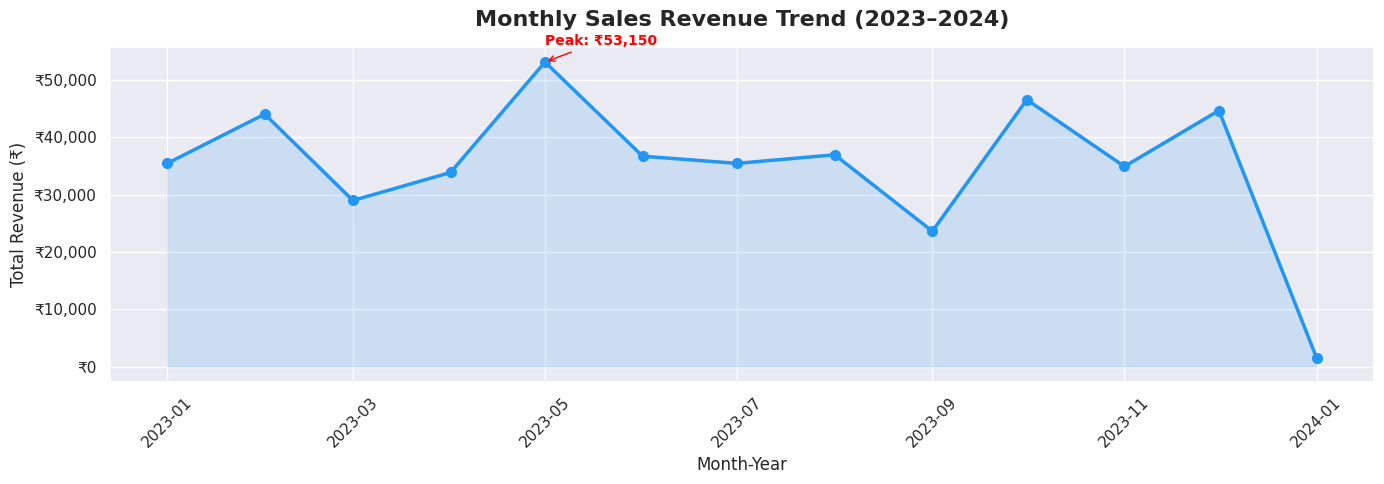

✅ Saved: monthly_sales_trend.png


In [8]:
monthly = df.groupby(['Year','Month'])['Total Amount'].sum().reset_index()
monthly['Period'] = pd.to_datetime(monthly[['Year','Month']].assign(day=1))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['Period'], monthly['Total Amount'],
        marker='o', color='#2196F3', linewidth=2.5, markersize=7)
ax.fill_between(monthly['Period'], monthly['Total Amount'],
                alpha=0.15, color='#2196F3')

# Annotate peak
peak_idx = monthly['Total Amount'].idxmax()
peak_val = monthly['Total Amount'].max()
peak_period = monthly.loc[peak_idx, 'Period']
ax.annotate(f'Peak: ₹{peak_val:,.0f}',
            xy=(peak_period, peak_val),
            xytext=(peak_period, peak_val + 3000),
            fontsize=10, color='red', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='red'))

ax.set_title('Monthly Sales Revenue Trend (2023–2024)',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Month-Year', fontsize=12)
ax.set_ylabel('Total Revenue (₹)', fontsize=12)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('images/monthly_sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: monthly_sales_trend.png")

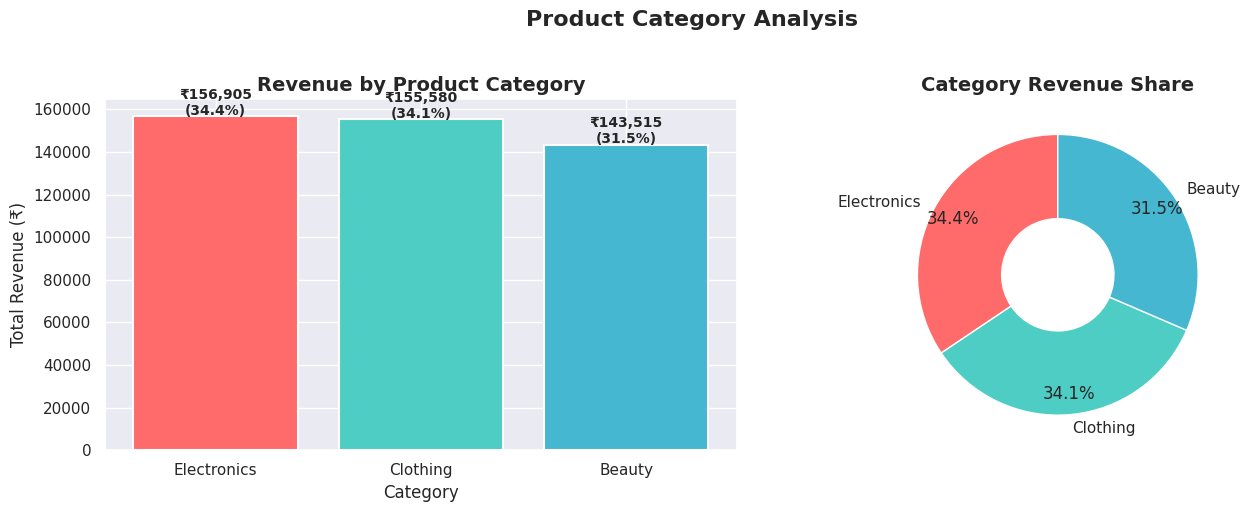

✅ Saved: sales_by_category.png


In [9]:
cat_sales = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
cat_pct   = (cat_sales / cat_sales.sum() * 100).round(1)

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(cat_sales.index, cat_sales.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Revenue by Product Category', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Total Revenue (₹)')
for bar, pct in zip(bars, cat_pct):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 500,
                 f'₹{bar.get_height():,.0f}\n({pct}%)',
                 ha='center', fontsize=10, fontweight='bold')

# Pie chart
axes[1].pie(cat_sales, labels=cat_sales.index,
            autopct='%1.1f%%', colors=colors,
            startangle=90, pctdistance=0.85,
            wedgeprops=dict(width=0.6))
axes[1].set_title('Category Revenue Share', fontsize=14, fontweight='bold')

plt.suptitle('Product Category Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/sales_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: sales_by_category.png")

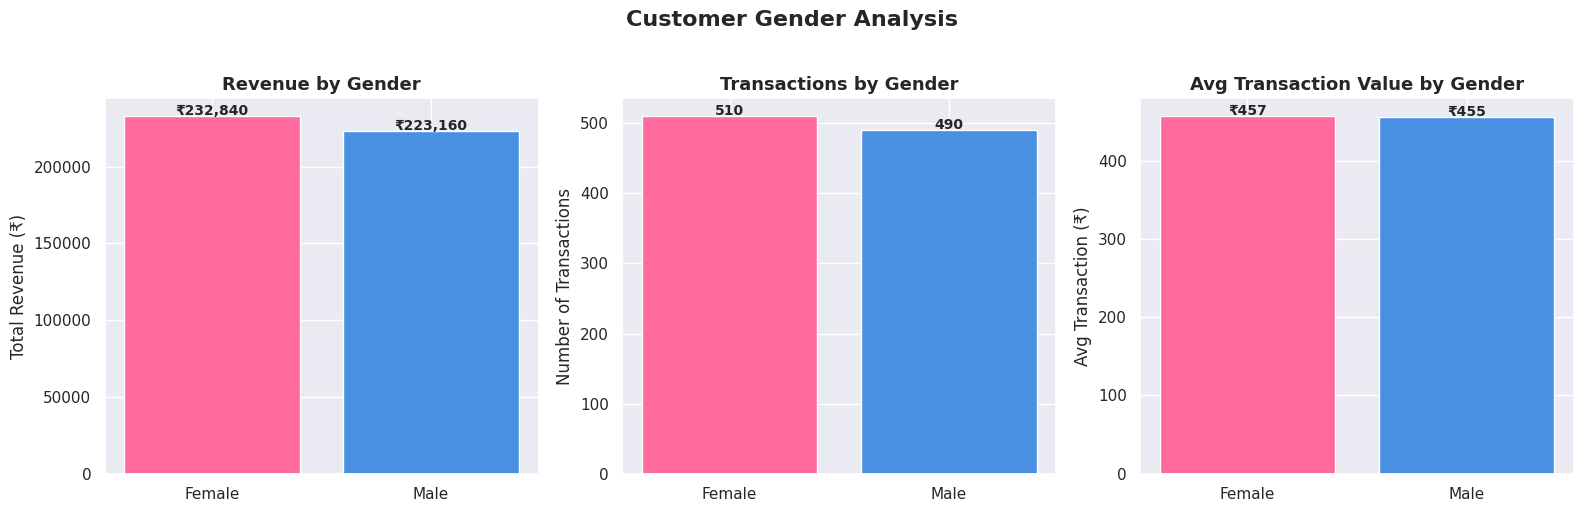

✅ Saved: gender_analysis.png


In [10]:
gender_rev   = df.groupby('Gender')['Total Amount'].sum()
gender_count = df.groupby('Gender')['Transaction ID'].count()
gender_avg   = df.groupby('Gender')['Total Amount'].mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors_g = ['#FF6B9D', '#4A90E2']

# Revenue
axes[0].bar(gender_rev.index, gender_rev.values, color=colors_g, edgecolor='white')
axes[0].set_title('Revenue by Gender', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Total Revenue (₹)')
for i, v in enumerate(gender_rev.values):
    axes[0].text(i, v + 500, f'₹{v:,.0f}', ha='center', fontsize=10, fontweight='bold')

# Transaction count
axes[1].bar(gender_count.index, gender_count.values, color=colors_g, edgecolor='white')
axes[1].set_title('Transactions by Gender', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Transactions')
for i, v in enumerate(gender_count.values):
    axes[1].text(i, v + 2, str(v), ha='center', fontsize=10, fontweight='bold')

# Avg transaction
axes[2].bar(gender_avg.index, gender_avg.values, color=colors_g, edgecolor='white')
axes[2].set_title('Avg Transaction Value by Gender', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Avg Transaction (₹)')
for i, v in enumerate(gender_avg.values):
    axes[2].text(i, v + 2, f'₹{v:,.0f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Customer Gender Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/gender_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: gender_analysis.png")

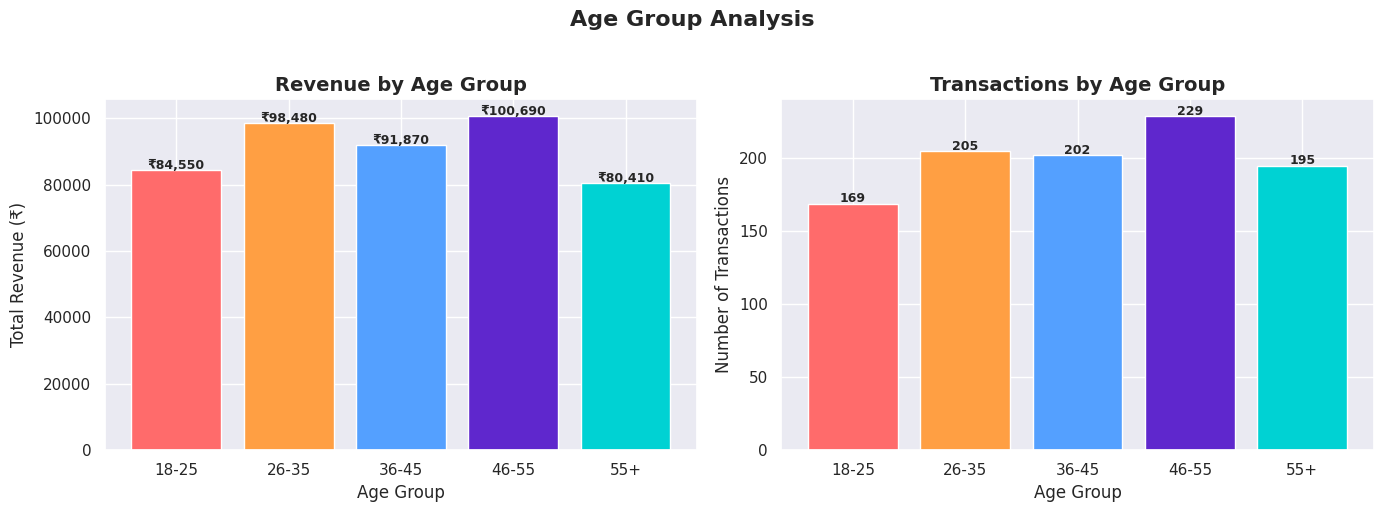

✅ Saved: age_group_analysis.png


In [11]:
age_rev   = df.groupby('Age Group', observed=True)['Total Amount'].sum()
age_count = df.groupby('Age Group', observed=True)['Transaction ID'].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_a = ['#FF6B6B','#FF9F43','#54A0FF','#5F27CD','#00D2D3']

axes[0].bar(age_rev.index.astype(str), age_rev.values, color=colors_a, edgecolor='white')
axes[0].set_title('Revenue by Age Group', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Total Revenue (₹)')
for i, v in enumerate(age_rev.values):
    axes[0].text(i, v + 300, f'₹{v:,.0f}', ha='center', fontsize=9, fontweight='bold')

axes[1].bar(age_count.index.astype(str), age_count.values, color=colors_a, edgecolor='white')
axes[1].set_title('Transactions by Age Group', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Number of Transactions')
for i, v in enumerate(age_count.values):
    axes[1].text(i, v + 1, str(v), ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Age Group Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/age_group_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: age_group_analysis.png")

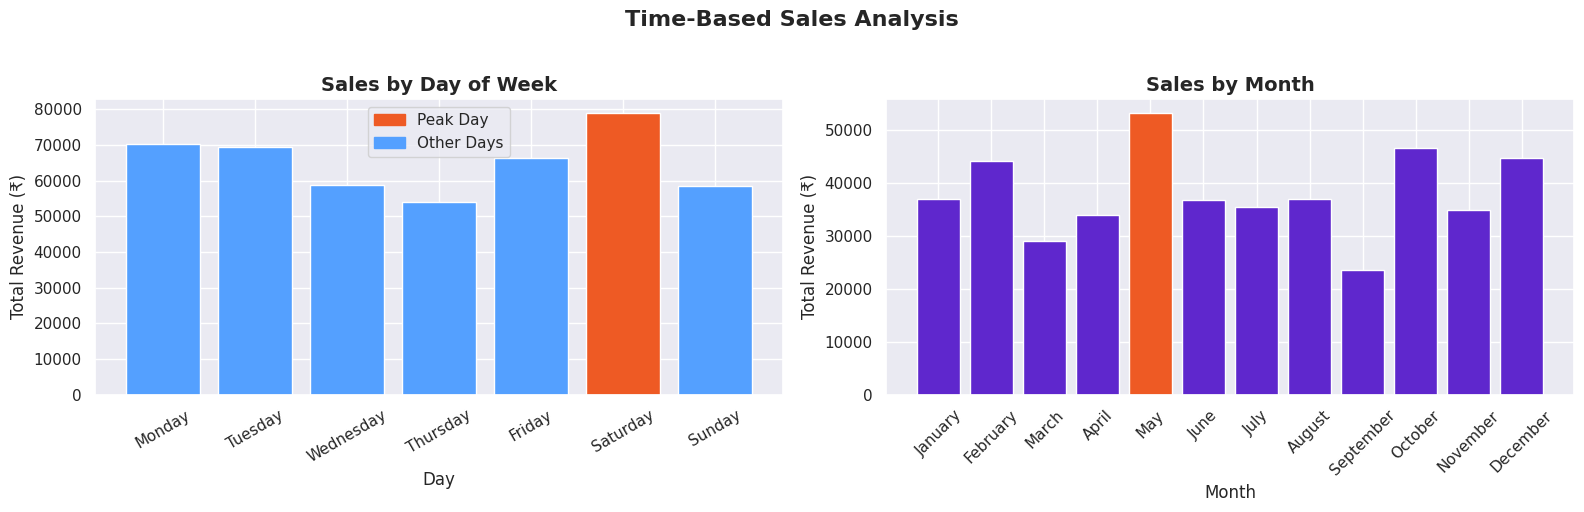

✅ Saved: time_analysis.png


In [12]:
day_order   = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

day_sales   = df.groupby('Weekday')['Total Amount'].sum().reindex(day_order)
month_sales = df.groupby('Month_Name')['Total Amount'].sum().reindex(month_order).dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Weekday
colors_day = ['#EE5A24' if v == day_sales.max() else '#54A0FF' for v in day_sales]
axes[0].bar(day_sales.index, day_sales.values, color=colors_day, edgecolor='white')
axes[0].set_title('Sales by Day of Week', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Total Revenue (₹)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(handles=[
    mpatches.Patch(color='#EE5A24', label='Peak Day'),
    mpatches.Patch(color='#54A0FF', label='Other Days')
])

# Month
colors_month = ['#EE5A24' if v == month_sales.max() else '#5F27CD' for v in month_sales]
axes[1].bar(month_sales.index, month_sales.values, color=colors_month, edgecolor='white')
axes[1].set_title('Sales by Month', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total Revenue (₹)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Time-Based Sales Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/time_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: time_analysis.png")

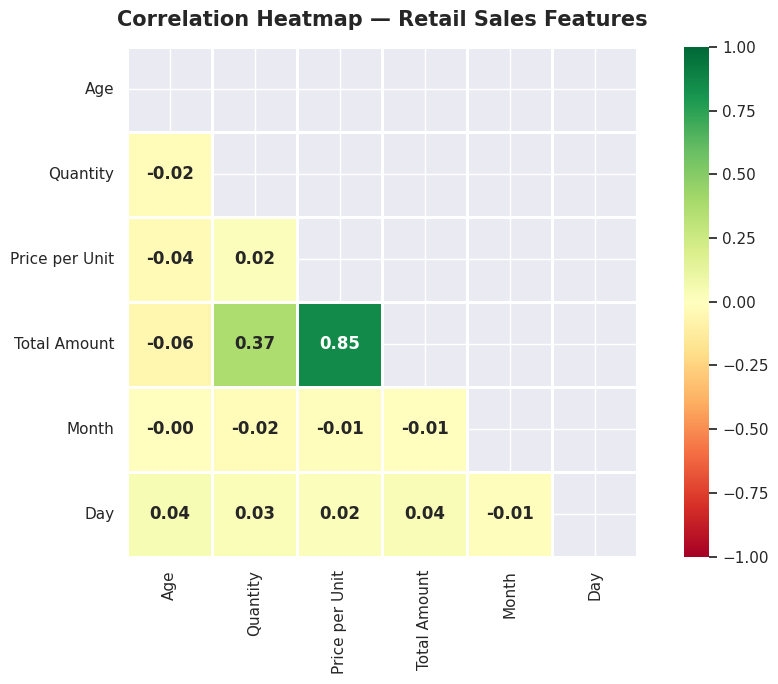

✅ Saved: correlation_heatmap.png


In [13]:
numeric_cols = df[['Age','Quantity','Price per Unit','Total Amount','Month','Day']]
corr = numeric_cols.corr()

plt.figure(figsize=(10, 7))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.8, square=True, mask=mask,
            annot_kws={'size': 12, 'weight': 'bold'},
            vmin=-1, vmax=1)
plt.title('Correlation Heatmap — Retail Sales Features',
          fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('images/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: correlation_heatmap.png")

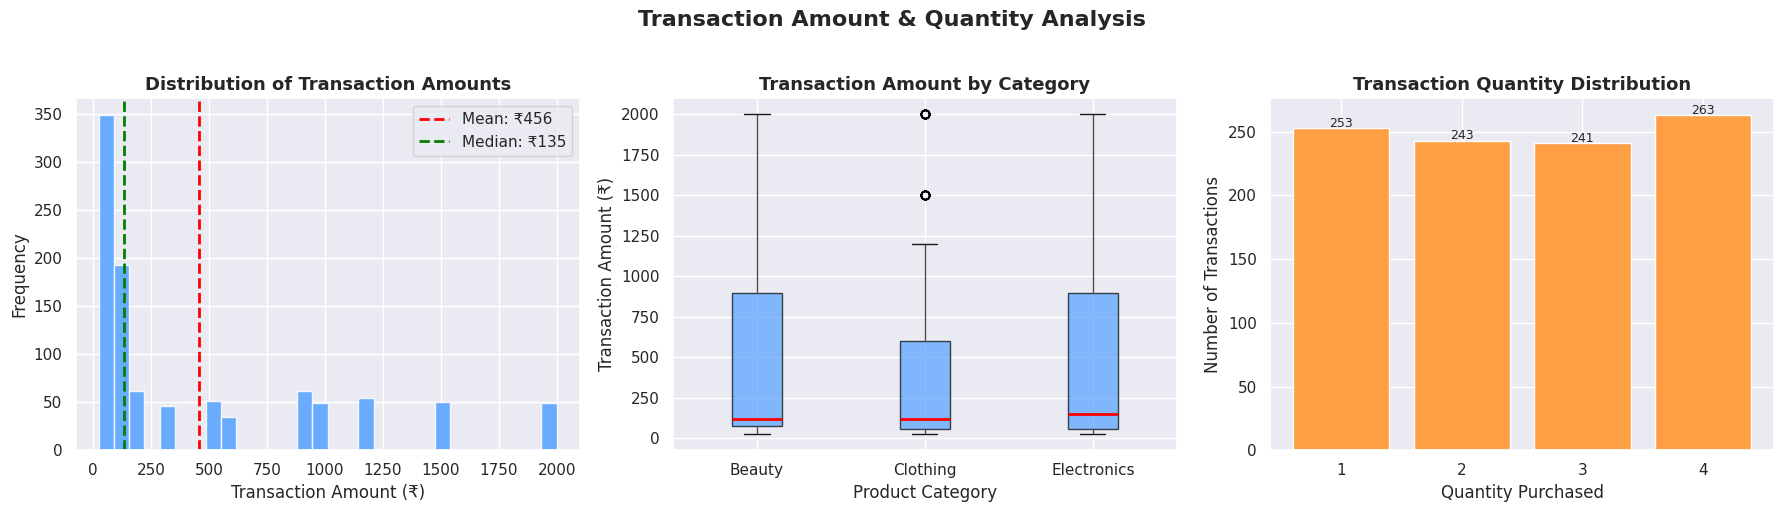

✅ Saved: distribution_analysis.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(df['Total Amount'], bins=30,
             color='#54A0FF', edgecolor='white', alpha=0.85)
axes[0].axvline(df['Total Amount'].mean(), color='red',
                linestyle='--', linewidth=2, label=f"Mean: ₹{df['Total Amount'].mean():,.0f}")
axes[0].axvline(df['Total Amount'].median(), color='green',
                linestyle='--', linewidth=2, label=f"Median: ₹{df['Total Amount'].median():,.0f}")
axes[0].set_title('Distribution of Transaction Amounts', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Transaction Amount (₹)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Boxplot by Category
df.boxplot(column='Total Amount', by='Product Category',
           ax=axes[1], patch_artist=True,
           boxprops=dict(facecolor='#54A0FF', alpha=0.7),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Transaction Amount by Category', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Product Category')
axes[1].set_ylabel('Transaction Amount (₹)')
plt.sca(axes[1])
plt.title('Transaction Amount by Category', fontsize=13, fontweight='bold')

# Quantity distribution
qty_counts = df['Quantity'].value_counts().sort_index()
axes[2].bar(qty_counts.index.astype(str), qty_counts.values,
            color='#FF9F43', edgecolor='white')
axes[2].set_title('Transaction Quantity Distribution', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Quantity Purchased')
axes[2].set_ylabel('Number of Transactions')
for i, v in enumerate(qty_counts.values):
    axes[2].text(i, v + 1, str(v), ha='center', fontsize=9)

plt.suptitle('Transaction Amount & Quantity Analysis',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/distribution_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: distribution_analysis.png")

     OUTLIER DETECTION — IQR METHOD
  Q1 (25th percentile)  : ₹60.00
  Q3 (75th percentile)  : ₹900.00
  IQR                   : ₹840.00
  Lower Bound           : ₹-1,200.00
  Upper Bound           : ₹2,160.00
  Total Outliers Found  : 0
  Outlier Percentage    : 0.00%


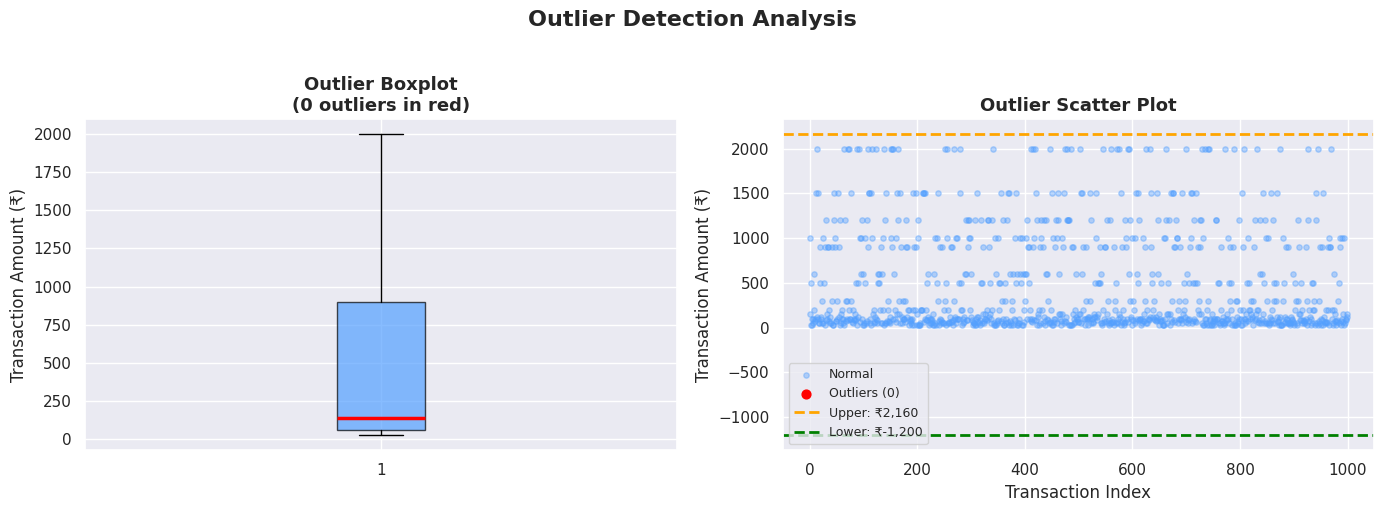

✅ Saved: outlier_detection.png


In [15]:
print("=" * 55)
print("     OUTLIER DETECTION — IQR METHOD")
print("=" * 55)

Q1 = df['Total Amount'].quantile(0.25)
Q3 = df['Total Amount'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Total Amount'] < lower) | (df['Total Amount'] > upper)]

print(f"  Q1 (25th percentile)  : ₹{Q1:,.2f}")
print(f"  Q3 (75th percentile)  : ₹{Q3:,.2f}")
print(f"  IQR                   : ₹{IQR:,.2f}")
print(f"  Lower Bound           : ₹{lower:,.2f}")
print(f"  Upper Bound           : ₹{upper:,.2f}")
print(f"  Total Outliers Found  : {len(outliers)}")
print(f"  Outlier Percentage    : {len(outliers)/len(df)*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
bp = axes[0].boxplot(df['Total Amount'], vert=True, patch_artist=True,
                     boxprops=dict(facecolor='#54A0FF', alpha=0.7),
                     flierprops=dict(marker='o', color='red',
                                     markerfacecolor='red', markersize=7),
                     medianprops=dict(color='red', linewidth=2.5))
axes[0].set_title(f'Outlier Boxplot\n({len(outliers)} outliers in red)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Transaction Amount (₹)')

# Scatter
axes[1].scatter(range(len(df)), df['Total Amount'],
                color='#54A0FF', alpha=0.4, s=15, label='Normal')
axes[1].scatter(outliers.index, outliers['Total Amount'],
                color='red', s=40, label=f'Outliers ({len(outliers)})', zorder=5)
axes[1].axhline(y=upper, color='orange', linestyle='--',
                linewidth=2, label=f'Upper: ₹{upper:,.0f}')
axes[1].axhline(y=lower, color='green', linestyle='--',
                linewidth=2, label=f'Lower: ₹{lower:,.0f}')
axes[1].set_title('Outlier Scatter Plot', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Transaction Index')
axes[1].set_ylabel('Transaction Amount (₹)')
axes[1].legend(fontsize=9)

plt.suptitle('Outlier Detection Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/outlier_detection.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: outlier_detection.png")

In [16]:
print("=" * 55)
print("     RFM ANALYSIS")
print("=" * 55)

ref_date = df['Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    Recency   = ('Date', lambda x: (ref_date - x.max()).days),
    Frequency = ('Transaction ID', 'count'),
    Monetary  = ('Total Amount', 'sum')
).reset_index()

rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4,
                          labels=[4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'),
                          q=4, labels=[1,2,3,4]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4,
                          labels=[1,2,3,4]).astype(int)

rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

def segment(score):
    if score >= 10:   return 'Champions'
    elif score >= 8:  return 'Loyal Customers'
    elif score >= 6:  return 'Potential Loyalists'
    elif score >= 4:  return 'At Risk'
    else:             return 'Lost Customers'

rfm['Segment'] = rfm['RFM_Score'].apply(segment)

print("\nRFM Table (Top 10):")
print(rfm[['Customer ID','Recency','Frequency','Monetary',
           'RFM_Score','Segment']].head(10).to_string())
print(f"\nSegment Counts:\n{rfm['Segment'].value_counts()}")

     RFM ANALYSIS

RFM Table (Top 10):
  Customer ID  Recency  Frequency  Monetary  RFM_Score              Segment
0     CUST001       39          1       150          8      Loyal Customers
1     CUST002      309          1      1000          6  Potential Loyalists
2     CUST003      354          1        30          3       Lost Customers
3     CUST004      226          1       500          6  Potential Loyalists
4     CUST005      241          1       100          5              At Risk
5     CUST006      252          1        30          4              At Risk
6     CUST007      295          1        50          3       Lost Customers
7     CUST008      314          1       100          4              At Risk
8     CUST009       20          1       600          8      Loyal Customers
9     CUST010       87          1       200          8      Loyal Customers

Segment Counts:
Segment
Potential Loyalists    351
Loyal Customers        347
At Risk                149
Champions          

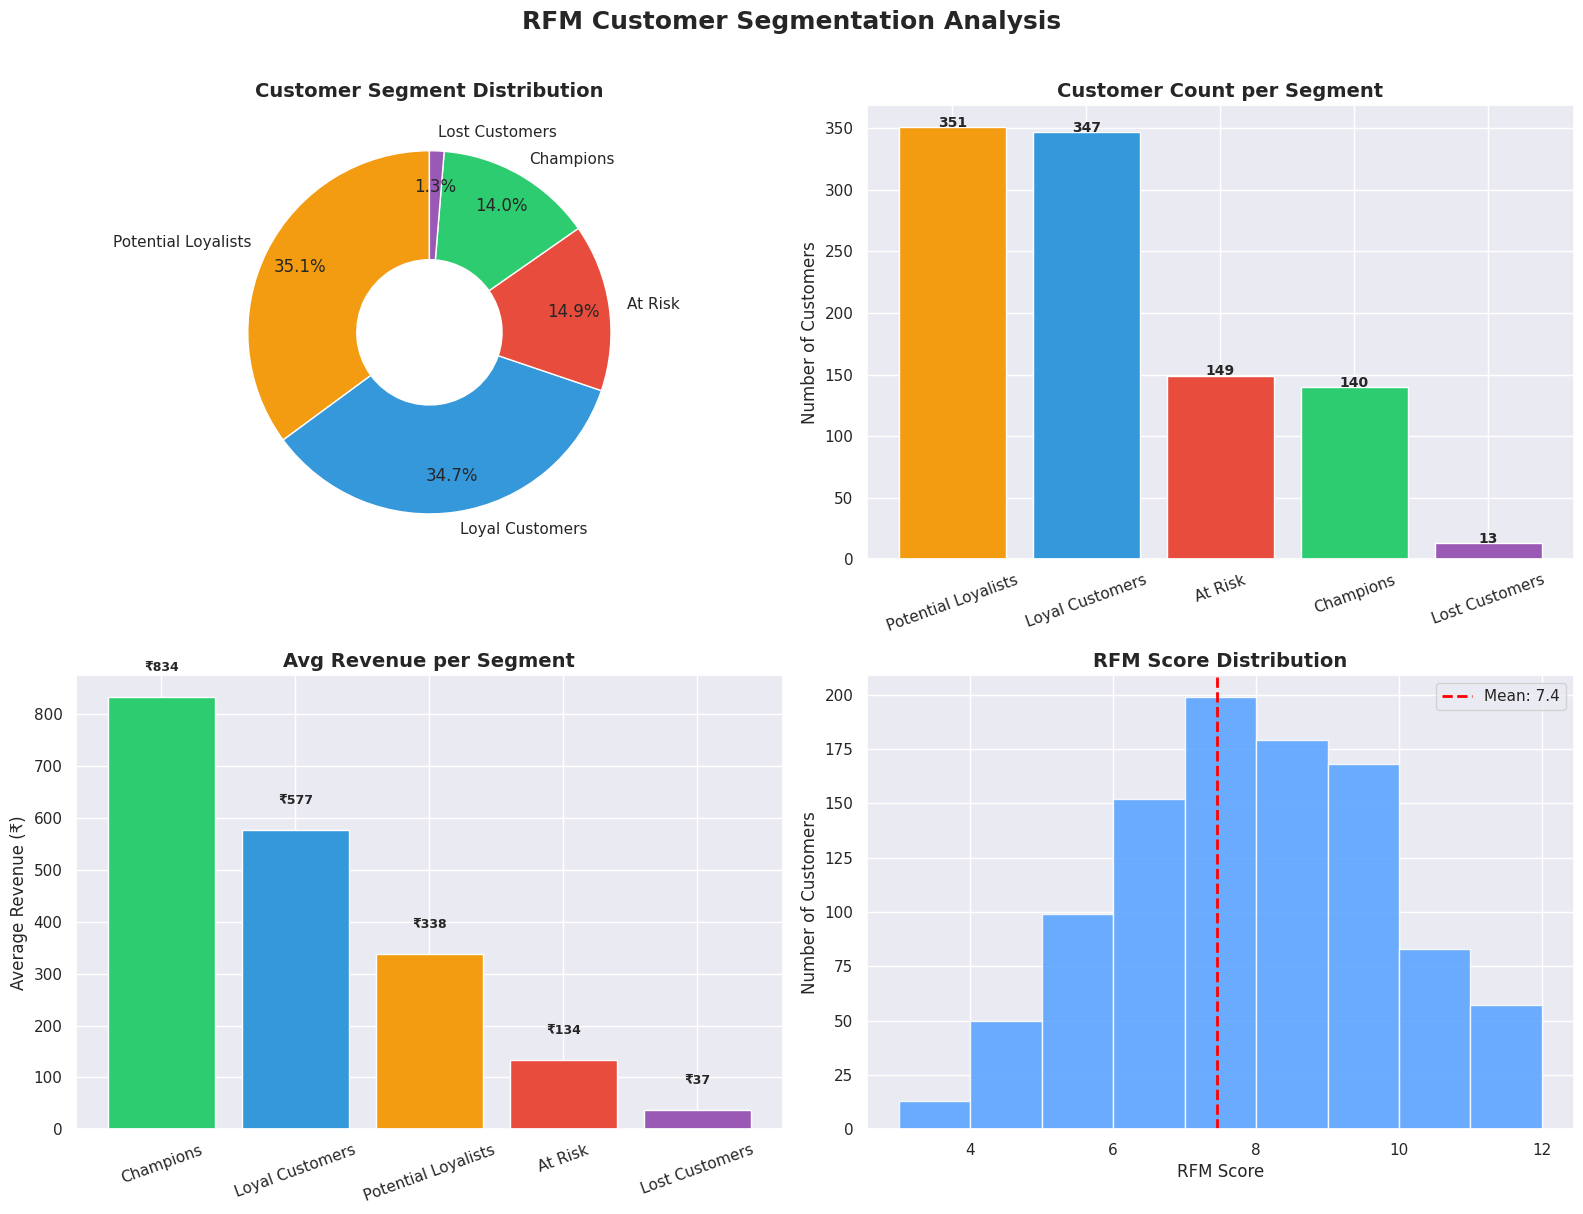

✅ Saved: rfm_analysis.png


In [17]:
seg_colors = {
    'Champions'         : '#2ecc71',
    'Loyal Customers'   : '#3498db',
    'Potential Loyalists': '#f39c12',
    'At Risk'           : '#e74c3c',
    'Lost Customers'    : '#9b59b6'
}
seg_counts  = rfm['Segment'].value_counts()
seg_monetary = rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=False)
colors_seg  = [seg_colors[s] for s in seg_counts.index]
colors_seg2 = [seg_colors[s] for s in seg_monetary.index]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Segment distribution pie
axes[0,0].pie(seg_counts, labels=seg_counts.index,
              autopct='%1.1f%%', colors=colors_seg,
              startangle=90, pctdistance=0.8,
              wedgeprops=dict(width=0.6))
axes[0,0].set_title('Customer Segment Distribution',
                     fontsize=14, fontweight='bold')

# Segment count bar
bars = axes[0,1].bar(seg_counts.index, seg_counts.values,
                     color=colors_seg, edgecolor='white')
axes[0,1].set_title('Customer Count per Segment',
                     fontsize=14, fontweight='bold')
axes[0,1].set_ylabel('Number of Customers')
axes[0,1].tick_params(axis='x', rotation=20)
for bar in bars:
    axes[0,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.3,
                   str(int(bar.get_height())),
                   ha='center', fontsize=10, fontweight='bold')

# Avg monetary per segment
bars2 = axes[1,0].bar(seg_monetary.index, seg_monetary.values,
                      color=colors_seg2, edgecolor='white')
axes[1,0].set_title('Avg Revenue per Segment',
                     fontsize=14, fontweight='bold')
axes[1,0].set_ylabel('Average Revenue (₹)')
axes[1,0].tick_params(axis='x', rotation=20)
for bar in bars2:
    axes[1,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 50,
                   f'₹{bar.get_height():,.0f}',
                   ha='center', fontsize=9, fontweight='bold')

# RFM Score distribution
axes[1,1].hist(rfm['RFM_Score'], bins=range(3,13),
               color='#54A0FF', edgecolor='white', alpha=0.85)
axes[1,1].set_title('RFM Score Distribution',
                     fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('RFM Score')
axes[1,1].set_ylabel('Number of Customers')
axes[1,1].axvline(rfm['RFM_Score'].mean(), color='red',
                  linestyle='--', linewidth=2,
                  label=f"Mean: {rfm['RFM_Score'].mean():.1f}")
axes[1,1].legend()

plt.suptitle('RFM Customer Segmentation Analysis',
             fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/rfm_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: rfm_analysis.png")

     DATASET 2 — McDONALD'S MENU EDA


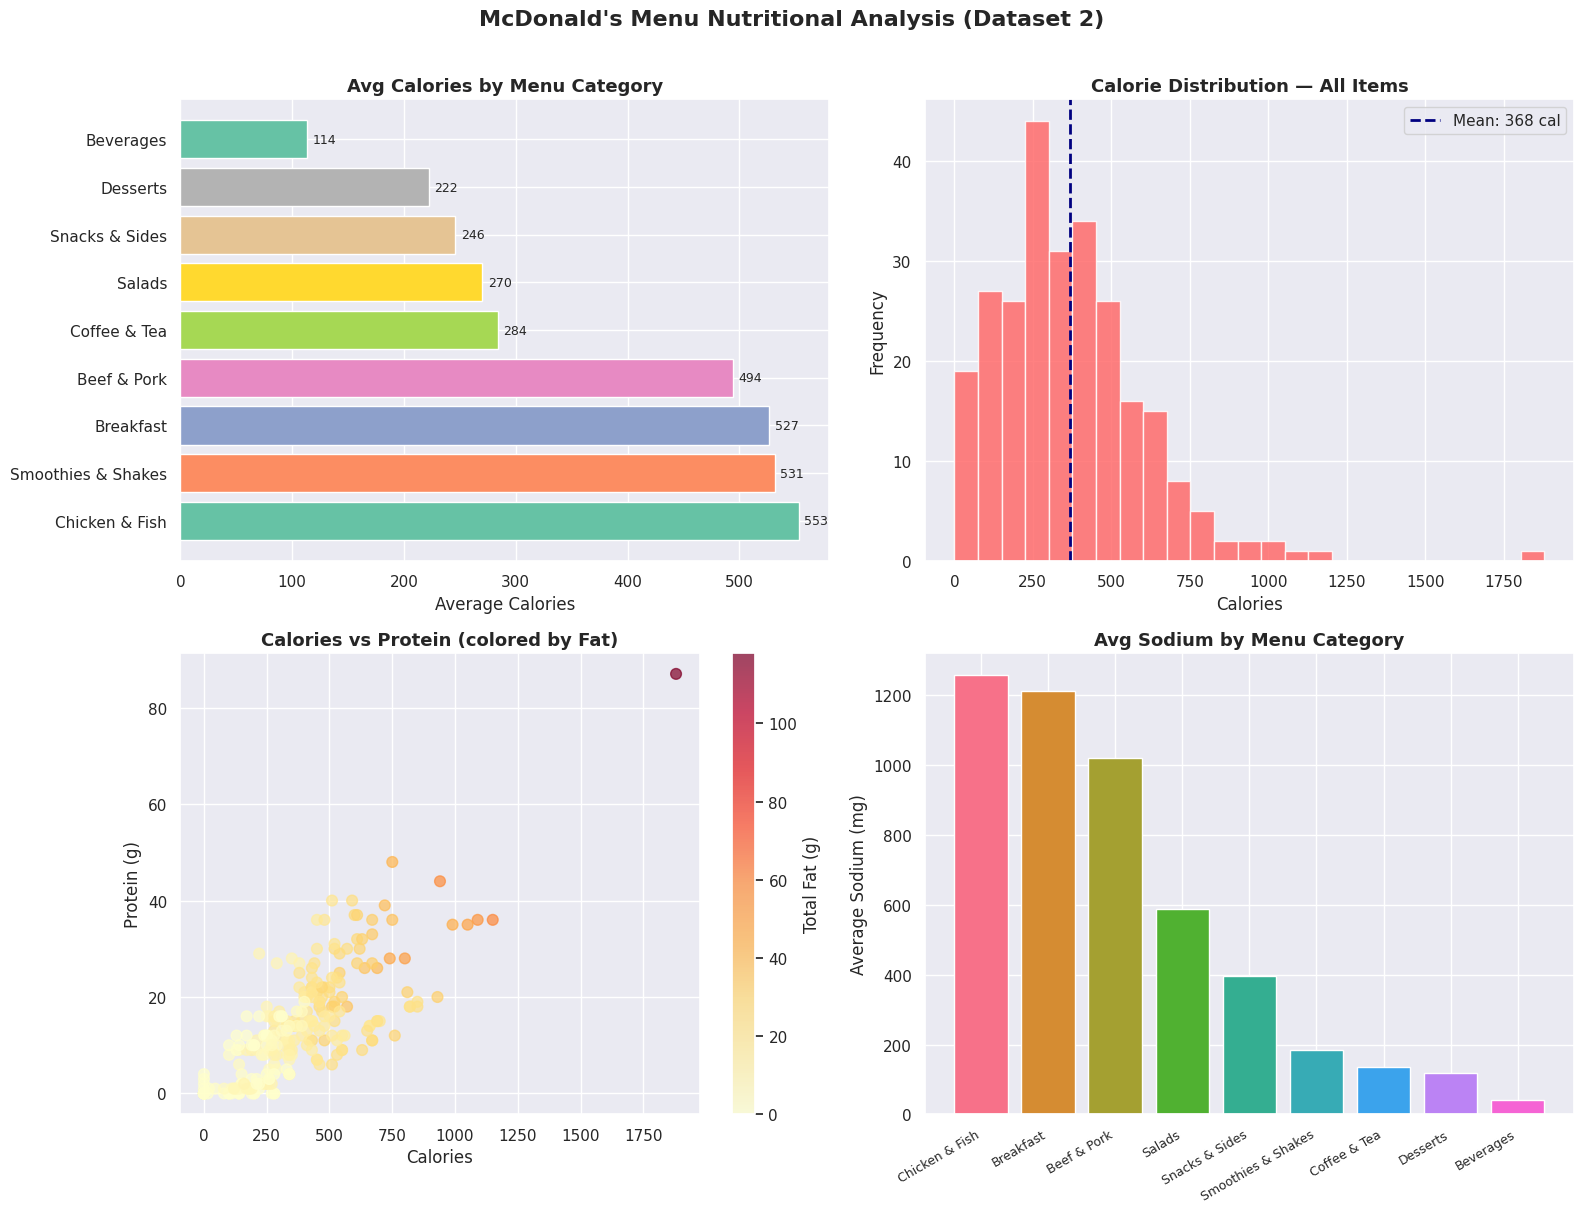

✅ Saved: menu_analysis.png


In [18]:
print("=" * 55)
print("     DATASET 2 — McDONALD'S MENU EDA")
print("=" * 55)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Calories by category
cat_cal = menu.groupby('Category')['Calories'].mean().sort_values(ascending=False)
axes[0,0].barh(cat_cal.index, cat_cal.values,
               color=sns.color_palette('Set2', len(cat_cal)))
axes[0,0].set_title('Avg Calories by Menu Category',
                     fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Average Calories')
for i, v in enumerate(cat_cal.values):
    axes[0,0].text(v + 5, i, f'{v:.0f}', va='center', fontsize=9)

# Calories distribution
axes[0,1].hist(menu['Calories'], bins=25,
               color='#FF6B6B', edgecolor='white', alpha=0.85)
axes[0,1].axvline(menu['Calories'].mean(), color='navy',
                  linestyle='--', linewidth=2,
                  label=f"Mean: {menu['Calories'].mean():.0f} cal")
axes[0,1].set_title('Calorie Distribution — All Items',
                     fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Calories')
axes[0,1].set_ylabel('Frequency')
axes[0,1].legend()

# Protein vs Calories scatter
scatter = axes[1,0].scatter(menu['Calories'], menu['Protein'],
                             c=menu['Total Fat'], cmap='YlOrRd',
                             s=60, alpha=0.7)
plt.colorbar(scatter, ax=axes[1,0], label='Total Fat (g)')
axes[1,0].set_title('Calories vs Protein (colored by Fat)',
                     fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Calories')
axes[1,0].set_ylabel('Protein (g)')

# Sodium by category
cat_sod = menu.groupby('Category')['Sodium'].mean().sort_values(ascending=False)
axes[1,1].bar(range(len(cat_sod)), cat_sod.values,
              color=sns.color_palette('husl', len(cat_sod)),
              edgecolor='white')
axes[1,1].set_xticks(range(len(cat_sod)))
axes[1,1].set_xticklabels(cat_sod.index, rotation=30, ha='right', fontsize=9)
axes[1,1].set_title('Avg Sodium by Menu Category',
                     fontsize=13, fontweight='bold')
axes[1,1].set_ylabel('Average Sodium (mg)')

plt.suptitle("McDonald's Menu Nutritional Analysis (Dataset 2)",
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/menu_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: menu_analysis.png")

In [19]:
# Calculate real numbers
top_cat       = df.groupby('Product Category')['Total Amount'].sum().idxmax()
top_cat_pct   = (df.groupby('Product Category')['Total Amount'].sum().max() /
                 df['Total Amount'].sum() * 100)
peak_month    = df.groupby('Month_Name')['Total Amount'].sum().idxmax()
peak_month_val= df.groupby('Month_Name')['Total Amount'].sum().max()
top_age       = df.groupby('Age Group', observed=True)['Total Amount'].sum().idxmax()
top_age_pct   = (df.groupby('Age Group', observed=True)['Total Amount'].sum().max() /
                 df['Total Amount'].sum() * 100)
top_day       = df.groupby('Weekday')['Total Amount'].sum().idxmax()
top_seg       = rfm['Segment'].value_counts().idxmax()
top_seg_n     = rfm['Segment'].value_counts().max()

print("""
╔══════════════════════════════════════════════════════════════════╗
║           DATA-DRIVEN INSIGHTS & RECOMMENDATIONS                 ║
╠══════════════════════════════════════════════════════════════════╣
""")
print(f"  📌 INSIGHT 1 — Top Product Category")
print(f"     '{top_cat}' is the highest revenue category")
print(f"     contributing {top_cat_pct:.1f}% of total revenue")
print(f"     → Increase stock & promotions for this category\n")

print(f"  📌 INSIGHT 2 — Peak Sales Month")
print(f"     '{peak_month}' is the peak month with ₹{peak_month_val:,.0f} revenue")
print(f"     → Plan campaigns & inventory before this month\n")

print(f"  📌 INSIGHT 3 — Top Customer Age Group")
print(f"     Age group '{top_age}' contributes {top_age_pct:.1f}% of revenue")
print(f"     → Target with loyalty programs & personalized offers\n")

print(f"  📌 INSIGHT 4 — Peak Sales Day")
print(f"     '{top_day}' records the highest daily sales")
print(f"     → Schedule flash sales on this day\n")

print(f"  📌 INSIGHT 5 — Dominant Customer Segment")
print(f"     '{top_seg}' is the largest segment with {top_seg_n} customers")
print(f"     → Focus retention on At Risk & Lost segments\n")

print(f"  📌 INSIGHT 6 — Outlier Transactions")
print(f"     {len(outliers)} transactions exceed ₹{upper:,.0f}")
print(f"     → These are potential VIP customers\n")

print(f"  📌 INSIGHT 7 — Menu Dataset")
cat_cal_top = menu.groupby('Category')['Calories'].mean().idxmax()
print(f"     '{cat_cal_top}' has the highest avg calorie count")
print(f"     → High-calorie items need nutrition labeling\n")
print("╚══════════════════════════════════════════════════════════════════╝")


╔══════════════════════════════════════════════════════════════════╗
║           DATA-DRIVEN INSIGHTS & RECOMMENDATIONS                 ║
╠══════════════════════════════════════════════════════════════════╣

  📌 INSIGHT 1 — Top Product Category
     'Electronics' is the highest revenue category
     contributing 34.4% of total revenue
     → Increase stock & promotions for this category

  📌 INSIGHT 2 — Peak Sales Month
     'May' is the peak month with ₹53,150 revenue
     → Plan campaigns & inventory before this month

  📌 INSIGHT 3 — Top Customer Age Group
     Age group '46-55' contributes 22.1% of revenue
     → Target with loyalty programs & personalized offers

  📌 INSIGHT 4 — Peak Sales Day
     'Saturday' records the highest daily sales
     → Schedule flash sales on this day

  📌 INSIGHT 5 — Dominant Customer Segment
     'Potential Loyalists' is the largest segment with 351 customers
     → Focus retention on At Risk & Lost segments

  📌 INSIGHT 6 — Outlier Transactions
   

In [20]:
df.to_csv('data/retail_sales_cleaned.csv', index=False)
rfm.to_csv('data/rfm_analysis.csv', index=False)
menu.to_csv('data/menu_cleaned.csv', index=False)

print("✅ Exported: retail_sales_cleaned.csv")
print("✅ Exported: rfm_analysis.csv")
print("✅ Exported: menu_cleaned.csv")
print(f"\nRetail Sales Shape  : {df.shape}")
print(f"RFM Shape           : {rfm.shape}")
print(f"Menu Shape          : {menu.shape}")

✅ Exported: retail_sales_cleaned.csv
✅ Exported: rfm_analysis.csv
✅ Exported: menu_cleaned.csv

Retail Sales Shape  : (1000, 16)
RFM Shape           : (1000, 9)
Menu Shape          : (260, 24)


In [23]:
print("=" * 60)
print("   EDA ON RETAIL SALES DATA — SUMMARY      ")
print("=" * 60)
print(f"  Dataset 1 Records        : {len(df):,}")
print(f"  Dataset 2 Records        : {len(menu):,}")
print(f"  Total Revenue Analyzed   : ₹{df['Total Amount'].sum():,.0f}")
print(f"  Avg Transaction Value    : ₹{df['Total Amount'].mean():,.2f}")
print(f"  Unique Customers         : {df['Customer ID'].nunique():,}")
print(f"  Product Categories       : {df['Product Category'].nunique()}")
print(f"  Outliers Detected        : {len(outliers)}")
print(f"  Customer Segments (RFM)  : {rfm['Segment'].nunique()}")
print(f"  Total Charts Generated   : 9")
print(f"  CSVs Exported            : 3")
print("=" * 60)
print("  Techniques Applied:")
print("   Data Loading & Cleaning")
print("   Feature Engineering (Time + Age Group)")
print("   Descriptive Statistics")
print("   Time Series Analysis")
print("   Product Category Analysis")
print("   Customer Demographics Analysis")
print("   Outlier Detection (IQR)")
print("   RFM Customer Segmentation")
print("   Multi-Dataset EDA (Retail + Menu)")
print("   Data-Driven Insights & Recommendations")
print("=" * 60)

   EDA ON RETAIL SALES DATA — SUMMARY      
  Dataset 1 Records        : 1,000
  Dataset 2 Records        : 260
  Total Revenue Analyzed   : ₹456,000
  Avg Transaction Value    : ₹456.00
  Unique Customers         : 1,000
  Product Categories       : 3
  Outliers Detected        : 0
  Customer Segments (RFM)  : 5
  Total Charts Generated   : 9
  CSVs Exported            : 3
  Techniques Applied:
   Data Loading & Cleaning
   Feature Engineering (Time + Age Group)
   Descriptive Statistics
   Time Series Analysis
   Product Category Analysis
   Customer Demographics Analysis
   Outlier Detection (IQR)
   RFM Customer Segmentation
   Multi-Dataset EDA (Retail + Menu)
   Data-Driven Insights & Recommendations
